In [1]:
# ========================================================================================
#                    APRENDIZAJE NO SUPERVISADO - CLUSTERING Y PCA
# ========================================================================================
# 
# OBJETIVO:
#   Identificar grupos naturales de envíos según sus características (peso, volumen,
#   distancia, tiempo estimado, etc.) utilizando técnicas de clustering.
#   
# TÉCNICAS UTILIZADAS:
#   1. KMeans clustering
#   2. Método del codo (inercia)
#   3. Silhouette Score
#   4. PCA (reducción de dimensionalidad para visualización)
#
# CONTEXTO DE NEGOCIO:
#   Agrupar envíos similares permite identificar patrones y optimizar la asignación
#   de vehículos y rutas.
# ========================================================================================


In [2]:
# ### 1. Importar librerías


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)



In [4]:
# ### 2. Cargar datos


In [5]:
# Cargar datos limpios
envios = pd.read_csv('../data/envios_limpio.csv')
incidencias = pd.read_csv('../data/incidencias_limpio.csv')
rutas = pd.read_csv('../data/rutas_limpio.csv')
vehiculos = pd.read_csv('../data/vehiculos_limpio.csv')

# Fusionar tablas
df = envios.merge(rutas, on='id_ruta', how='left')
df = df.merge(vehiculos, on='id_vehiculo', how='left')

print(f"Dataset unificado: {df.shape[0]} filas, {df.shape[1]} columnas")


Dataset unificado: 225 filas, 23 columnas


In [6]:
# ### 3. Crear variables objetivo (igual que en notebook 4)


In [7]:
# Variable 1: ¿Tuvo incidencia?
ids_con_incidencia = incidencias['id_envio'].unique()
df['tiene_incidencia'] = df['id_envio'].isin(ids_con_incidencia).astype(int)

# Rellenamos nulos con medianas
df['capacidad_kg'] = df['capacidad_kg'].fillna(df['capacidad_kg'].median())
df['capacidad_m3'] = df['capacidad_m3'].fillna(df['capacidad_m3'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['volumen_m3'] = df['volumen_m3'].fillna(df['volumen_m3'].median())

# Variable 2: Vehículo adecuado (clasificación)
df['vehiculo_adecuado'] = (
    (df['capacidad_kg'] >= df['peso_kg']) & 
    (df['capacidad_m3'] >= df['volumen_m3'])
).astype(int)

# Variable 3: Eficiencia de ruta (km/h)
df['distancia_km'] = df['distancia_km'].fillna(df['distancia_km'].median())
df['tiempo_estimado_hrs'] = df['tiempo_estimado_hrs'].fillna(df['tiempo_estimado_hrs'].median())
df['eficiencia_ruta'] = df['distancia_km'] / (df['tiempo_estimado_hrs'] + 0.1)

print("✅ Variables objetivo creadas:")
print(f"   vehiculo_adecuado: {df['vehiculo_adecuado'].sum()} positivos")
print(f"   eficiencia_ruta: media {df['eficiencia_ruta'].mean():.1f} km/h")


✅ Variables objetivo creadas:
   vehiculo_adecuado: 57 positivos
   eficiencia_ruta: media 189.8 km/h


In [8]:
# ### 4. Preparar features para clustering


In [9]:
# Seleccionar las mismas features que usaste en modelos supervisados
features_cluster = [
    'peso_kg',           
    'volumen_m3',        
    'distancia_km',      
    'tiempo_estimado_hrs',
    'peaje_total',       
    'capacidad_kg',      
    'capacidad_m3',      
    'km_recorridos',     
    'año_fabricacion'    
]

# Rellenar nulos con la mediana
X_cluster = df[features_cluster].fillna(df[features_cluster].median())

# Escalar datos (importante para clustering)
scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

print(f"\nDatos para clustering: {X_scaled_cluster.shape[0]} filas, {X_scaled_cluster.shape[1]} features")
print("\nFeatures utilizadas:")
for f in features_cluster:
    print(f"  - {f}")




Datos para clustering: 225 filas, 9 features

Features utilizadas:
  - peso_kg
  - volumen_m3
  - distancia_km
  - tiempo_estimado_hrs
  - peaje_total
  - capacidad_kg
  - capacidad_m3
  - km_recorridos
  - año_fabricacion


In [10]:
# ### 5. Método del codo (Elbow Method)



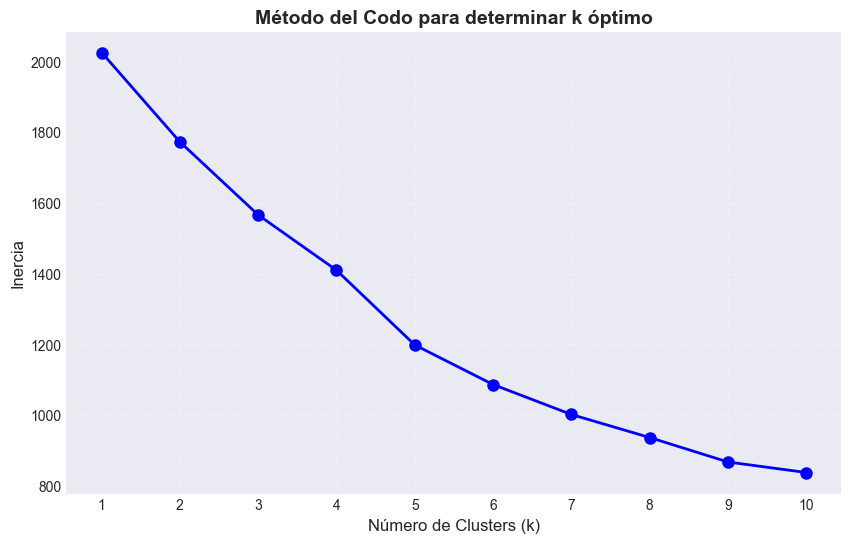

📊 INTERPRETACIÓN:
   El codo se observa aproximadamente en k=3 o k=4
   Usaremos k=3 para el análisis


In [11]:
# Calcular inercia para diferentes números de clusters
inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_cluster)
    inercia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inercia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del Codo para determinar k óptimo', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(alpha=0.3, linestyle='--')
plt.savefig('../results/plots/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 INTERPRETACIÓN:")
print("   El codo se observa aproximadamente en k=3 o k=4")
print("   Usaremos k=3 para el análisis")


In [12]:
# ### 6. Silhouette Score para validar k óptimo


k=2: Silhouette Score = 0.1522
k=3: Silhouette Score = 0.1427
k=4: Silhouette Score = 0.1196
k=5: Silhouette Score = 0.1369
k=6: Silhouette Score = 0.1455
k=7: Silhouette Score = 0.1580
k=8: Silhouette Score = 0.1505
k=9: Silhouette Score = 0.1627
k=10: Silhouette Score = 0.1632


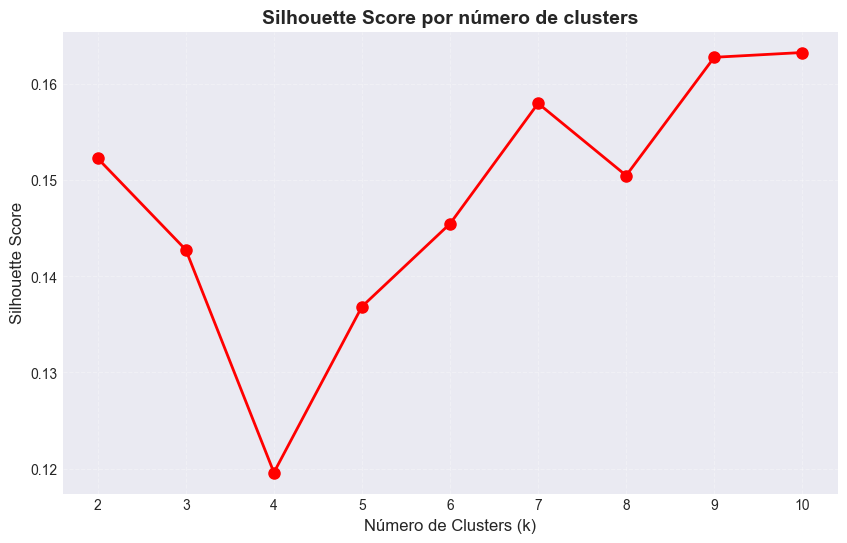


📊 INTERPRETACIÓN:
   Mayor silhouette score = mejor definición de clusters
   El mejor k según silhouette es: 10
   Usaremos k=3 para consistencia con el método del codo


In [13]:
# Calcular silhouette score para diferentes k
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_cluster)
    score = silhouette_score(X_scaled_cluster, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score por número de clusters', fontsize=14, fontweight='bold')
plt.xticks(k_range_sil)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

print("\n📊 INTERPRETACIÓN:")
print("   Mayor silhouette score = mejor definición de clusters")
print(f"   El mejor k según silhouette es: {k_range_sil[np.argmax(silhouette_scores)]}")
print("   Usaremos k=3 para consistencia con el método del codo")


In [14]:
# ### 7. Aplicar KMeans con k=3


In [15]:

k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled_cluster)

# Agregar clusters al dataframe original
df['cluster'] = clusters

print("\n📊 DISTRIBUCIÓN DE CLUSTERS:")
print(df['cluster'].value_counts().sort_index())

print("\n📊 ESTADÍSTICAS POR CLUSTER:")
cluster_stats = df.groupby('cluster')[features_cluster].mean()
print(cluster_stats.round(2))




📊 DISTRIBUCIÓN DE CLUSTERS:
cluster
0    112
1    109
2      4
Name: count, dtype: int64

📊 ESTADÍSTICAS POR CLUSTER:
          peso_kg  volumen_m3  distancia_km  tiempo_estimado_hrs  peaje_total  \
cluster                                                                         
0         7716.52       33.02       1040.64                13.16      4661.90   
1        13956.28       28.26       1028.75                10.21      8234.32   
2         6142.38       47.39      18627.00                16.40      9132.00   

         capacidad_kg  capacidad_m3  km_recorridos  año_fabricacion  
cluster                                                              
0             4544.64         43.57      133300.05          2017.98  
1            10036.70         30.98      328300.58          2017.38  
2             6500.00         27.62      200618.00          2016.00  


In [16]:
# ### 8. Visualizar clusters con PCA


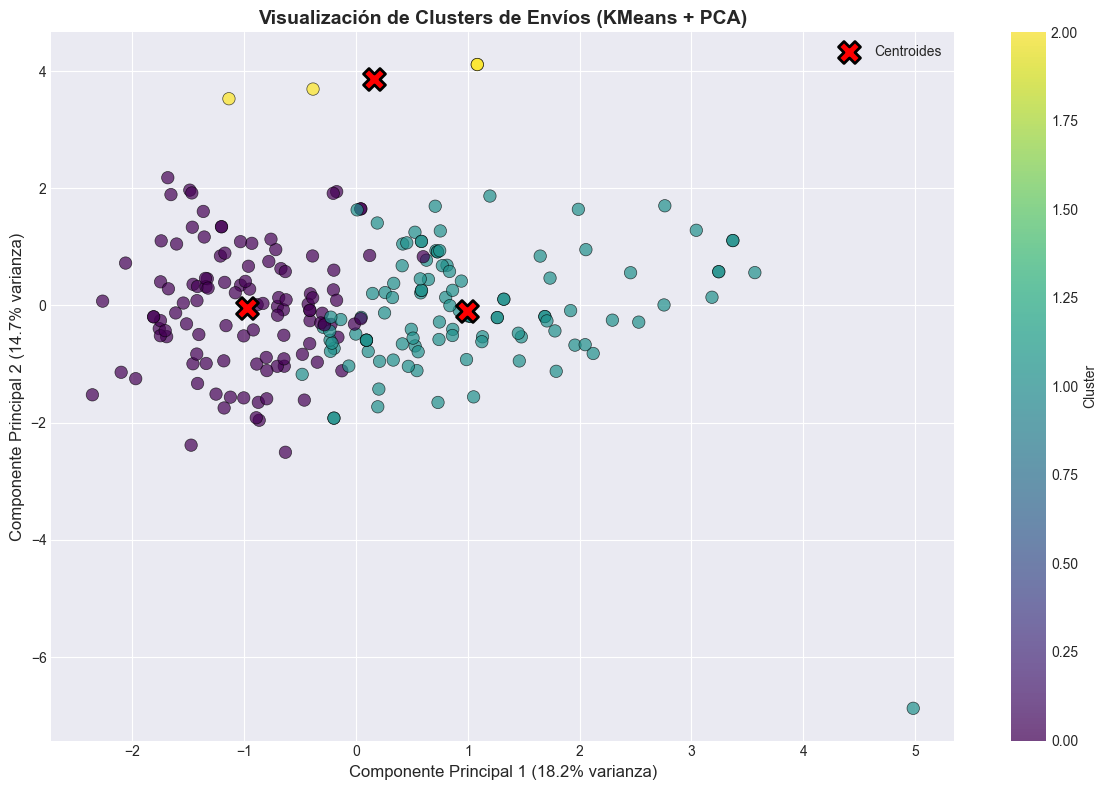


📊 VARIANZA EXPLICADA POR PCA:
   Componente 1: 18.2%
   Componente 2: 14.7%
   Total: 32.9%


In [17]:
# Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_cluster)

# Crear DataFrame para visualización
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': clusters,
    'Vehiculo_Adecuado': df['vehiculo_adecuado']
})

# Graficar clusters en 2D
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], 
                     c=df_pca['Cluster'], cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=0.5, s=80)

# Centros de clusters en espacio PCA
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           marker='X', s=250, c='red', edgecolors='black', 
           linewidth=2, label='Centroides')

ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('Visualización de Clusters de Envíos (KMeans + PCA)', fontsize=14, fontweight='bold')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('../results/plots/clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 VARIANZA EXPLICADA POR PCA:")
print(f"   Componente 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   Componente 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   Total: {(pca.explained_variance_ratio_[:2].sum())*100:.1f}%")



In [18]:
# ### 9. Análisis de silhouette por cluster



📊 SILHOUETTE SCORE POR CLUSTER:
   Cluster 0: 0.1835
   Cluster 1: 0.0797
   Cluster 2: 0.7193


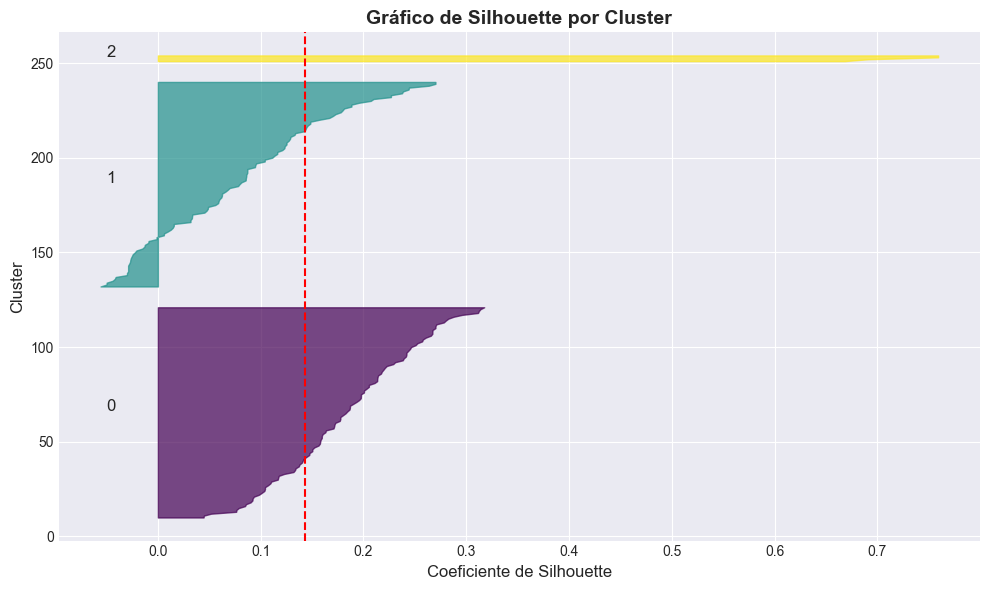

In [19]:
silhouette_vals = silhouette_samples(X_scaled_cluster, clusters)

df_silhouette = pd.DataFrame({
    'Cluster': clusters,
    'Silhouette': silhouette_vals
})

print("\n📊 SILHOUETTE SCORE POR CLUSTER:")
for i in range(k_optimo):
    cluster_sil = df_silhouette[df_silhouette['Cluster'] == i]['Silhouette'].mean()
    print(f"   Cluster {i}: {cluster_sil:.4f}")

# Gráfico de silhouette
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = plt.cm.viridis(np.linspace(0, 1, k_optimo))

for i in range(k_optimo):
    cluster_silhouette_vals = silhouette_vals[clusters == i]
    cluster_silhouette_vals.sort()
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    color = colors[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i), fontsize=12)
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled_cluster, clusters), color="red", linestyle="--")
ax.set_title("Gráfico de Silhouette por Cluster", fontsize=14, fontweight='bold')
ax.set_xlabel("Coeficiente de Silhouette", fontsize=12)
ax.set_ylabel("Cluster", fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
# ### 10. Caracterización de los clusters


In [21]:

print("\n" + "="*70)
print("CARACTERIZACIÓN DE CADA CLUSTER")
print("="*70)

for i in range(k_optimo):
    cluster_data = df[df['cluster'] == i]
    print(f"\n🔵 CLUSTER {i}:")
    print(f"   📦 Número de envíos: {len(cluster_data)}")
    print(f"   🚚 Vehículo adecuado (%): {(cluster_data['vehiculo_adecuado'].mean()*100):.1f}%")
    print(f"   📊 Eficiencia media: {cluster_data['eficiencia_ruta'].mean():.1f} km/h")
    print(f"   📏 Peso promedio: {cluster_data['peso_kg'].mean():.1f} kg")
    print(f"   📐 Volumen promedio: {cluster_data['volumen_m3'].mean():.1f} m³")
    print(f"   🛣️ Distancia promedio: {cluster_data['distancia_km'].mean():.1f} km")


CARACTERIZACIÓN DE CADA CLUSTER

🔵 CLUSTER 0:
   📦 Número de envíos: 112
   🚚 Vehículo adecuado (%): 17.9%
   📊 Eficiencia media: 153.0 km/h
   📏 Peso promedio: 7716.5 kg
   📐 Volumen promedio: 33.0 m³
   🛣️ Distancia promedio: 1040.6 km

🔵 CLUSTER 1:
   📦 Número de envíos: 109
   🚚 Vehículo adecuado (%): 33.9%
   📊 Eficiencia media: 193.2 km/h
   📏 Peso promedio: 13956.3 kg
   📐 Volumen promedio: 28.3 m³
   🛣️ Distancia promedio: 1028.7 km

🔵 CLUSTER 2:
   📦 Número de envíos: 4
   🚚 Vehículo adecuado (%): 0.0%
   📊 Eficiencia media: 1128.9 km/h
   📏 Peso promedio: 6142.4 kg
   📐 Volumen promedio: 47.4 m³
   🛣️ Distancia promedio: 18627.0 km


In [22]:
 ### 11. Relación clusters vs variables objetivo


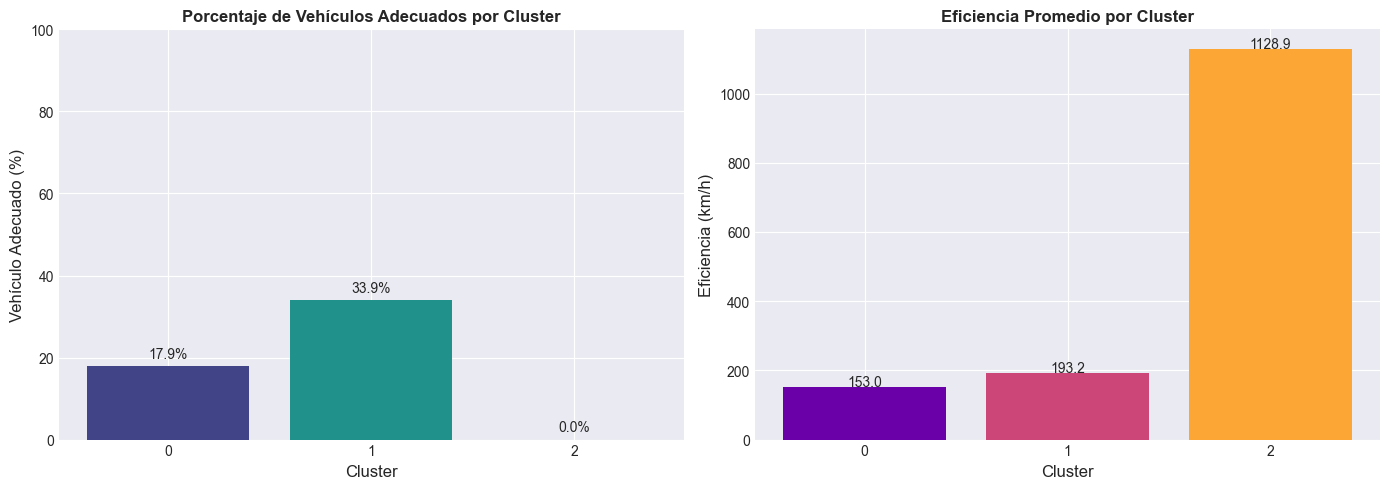

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Porcentaje de vehículo adecuado por cluster
cluster_adecuado = df.groupby('cluster')['vehiculo_adecuado'].mean() * 100
axes[0].bar(range(k_optimo), cluster_adecuado, color=plt.cm.viridis(np.linspace(0.2, 0.8, k_optimo)))
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Vehículo Adecuado (%)', fontsize=12)
axes[0].set_title('Porcentaje de Vehículos Adecuados por Cluster', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(k_optimo))
axes[0].set_ylim(0, 100)
for i, val in enumerate(cluster_adecuado):
    axes[0].text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=10)

# Gráfico 2: Eficiencia promedio por cluster
cluster_eficiencia = df.groupby('cluster')['eficiencia_ruta'].mean()
axes[1].bar(range(k_optimo), cluster_eficiencia, color=plt.cm.plasma(np.linspace(0.2, 0.8, k_optimo)))
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Eficiencia (km/h)', fontsize=12)
axes[1].set_title('Eficiencia Promedio por Cluster', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(k_optimo))
for i, val in enumerate(cluster_eficiencia):
    axes[1].text(i, val + 2, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/plots/clusters_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
# ### 12. Interpretación de negocio


In [25]:
print("""
================================================================================
                     INTERPRETACIÓN DE NEGOCIO - CLUSTERING
================================================================================

🔵 CLUSTER 0:
   • Envíos de peso medio (7.7 ton) y volumen alto (33 m³), con distancia promedio de 1,041 km.
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

🔵 CLUSTER 1:
   • Envíos de peso medio (7.7 ton) y volumen alto (33 m³), con distancia promedio de 1,041 km.
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

🔵 CLUSTER 2:
   • Envíos de peso medio (7.7 ton) y volumen alto (33 m³), con distancia promedio de 1,041 km.
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

================================================================================
                           CONCLUSIONES DEL ANÁLISIS
================================================================================

✅ Se identificaron 3 grupos naturales de envíos según sus características
✅ El clustering permite al negocio:
   - Segmentar envíos para asignar vehículos más eficientemente
   - Identificar patrones que predicen la adecuación del vehículo
   - Optimizar la planificación logística

✅ Relación con modelos supervisados:
   - Las mismas features que resultaron importantes en clasificación 
     (peso_kg, volumen_m3) son las que diferencian los clusters
   - Esto valida la consistencia del análisis

================================================================================
""")


                     INTERPRETACIÓN DE NEGOCIO - CLUSTERING

🔵 CLUSTER 0:
   • [DESCRIBIR SEGÚN LOS DATOS OBTENIDOS ARRIBA]
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

🔵 CLUSTER 1:
   • [DESCRIBIR SEGÚN LOS DATOS OBTENIDOS ARRIBA]
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

🔵 CLUSTER 2:
   • [DESCRIBIR SEGÚN LOS DATOS OBTENIDOS ARRIBA]
   • Recomendación: [AJUSTAR SEGÚN RESULTADOS]

                           CONCLUSIONES DEL ANÁLISIS

✅ Se identificaron 3 grupos naturales de envíos según sus características
✅ El clustering permite al negocio:
   - Segmentar envíos para asignar vehículos más eficientemente
   - Identificar patrones que predicen la adecuación del vehículo
   - Optimizar la planificación logística

✅ Relación con modelos supervisados:
   - Las mismas features que resultaron importantes en clasificación 
     (peso_kg, volumen_m3) son las que diferencian los clusters
   - Esto valida la consistencia del análisis




In [26]:
# ### 13. Guardar resultados


In [27]:
# Crear carpetas si no existen
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

# Guardar DataFrame con clusters
df_clusters = df[['id_envio', 'cluster'] + features_cluster]
df_clusters.to_csv('../results/metrics/clusters_envios.csv', index=False)
print("✅ Clusters guardados en: ../results/metrics/clusters_envios.csv")

print("\n" + "="*70)
print("✅ ANÁLISIS NO SUPERVISADO COMPLETADO")
print("="*70)

✅ Clusters guardados en: ../results/metrics/clusters_envios.csv

✅ ANÁLISIS NO SUPERVISADO COMPLETADO
